In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')


np.random.seed(42)
sns.set_style('whitegrid')

print("Libraries loaded!")

Libraries loaded!


In [3]:
n_records = 550

data = {
    'loan_id': range(1001, 1001 + n_records),
    'age': np.random.normal(45, 12, n_records).astype(int),
    'income': np.random.normal(75000, 35000, n_records).astype(int),
    'loan_amount': np.random.normal(150000, 80000, n_records).astype(int),
    'credit_score': np.random.normal(680, 100, n_records).astype(int),
    'employment_years': np.random.exponential(8, n_records).astype(int),
    'interest_rate': np.random.uniform(3.5, 12.5, n_records),
    'purpose': np.random.choice(['Home', 'Car', 'Education', 'Personal', 'Business'], n_records),
    'grade': np.random.choice(['A', 'B', 'C', 'D', 'E'], n_records, p=[0.25, 0.30, 0.25, 0.15, 0.05])
}

df = pd.DataFrame(data)
df['loan_status'] = np.random.choice([0, 1], n_records, p=[0.90, 0.10])
df['age'] = df['age'].clip(lower=21, upper=80)
df['income'] = df['income'].clip(lower=25000, upper=250000)
df['loan_amount'] = df['loan_amount'].clip(lower=10000, upper=500000)
df['credit_score'] = df['credit_score'].clip(lower=300, upper=850)
df['employment_years'] = df['employment_years'].clip(lower=0, upper=50)

print(f"✓ Dataset created: {df.shape}")
df.head()

✓ Dataset created: (550, 10)


,loan_id,age,income,loan_amount,credit_score,employment_years,interest_rate,purpose,grade,loan_status
0,1001,50,78030,229840,737,5,10.896479,Personal,D,0
1,1002,43,69551,10000,712,10,9.435597,Education,C,0
2,1003,52,115872,317069,699,2,10.666173,Education,B,0
3,1004,63,83904,138832,644,8,5.947514,Car,C,0
4,1005,42,86816,238654,713,8,9.731230,Education,C,0


In [4]:
print("=" * 60)
print("DATASET INFORMATION")
print("=" * 60)
print(f"Shape: {df.shape}")
print(f"Total Records: {df.shape[0]}")
print(f"Total Features: {df.shape[1]}")
print("\nData Types:")
print(df.dtypes)
print("\nBasic Statistics:")
df.describe().round(2)

DATASET INFORMATION
Shape: (550, 10)
Total Records: 550
Total Features: 10

Data Types:
loan_id               int64
age                   int64
income                int64
loan_amount           int64
credit_score          int64
employment_years      int64
interest_rate       float64
purpose              object
grade                object
loan_status           int64
dtype: object

Basic Statistics:


,loan_id,age,income,loan_amount,credit_score,employment_years,interest_rate,loan_status
count,550.00,550.00,550.00,550.00,550.00,550.00,550.00,550.00
mean,1275.50,44.36,78761.95,157085.05,678.43,7.04,8.01,0.11
std,158.92,11.46,32340.58,79586.74,93.37,7.02,2.59,0.32
min,1001.00,21.00,25000.00,10000.00,378.00,0.00,3.51,0.00
25%,1138.25,36.00,56147.50,97558.75,618.00,2.00,5.76,0.00
50%,1275.50,44.50,77720.00,154219.50,679.50,5.00,7.91,0.00
75%,1412.75,52.00,99786.75,209262.00,743.00,10.00,10.33,0.00
max,1550.00,80.00,167133.00,405448.00,850.00,46.00,12.50,1.00


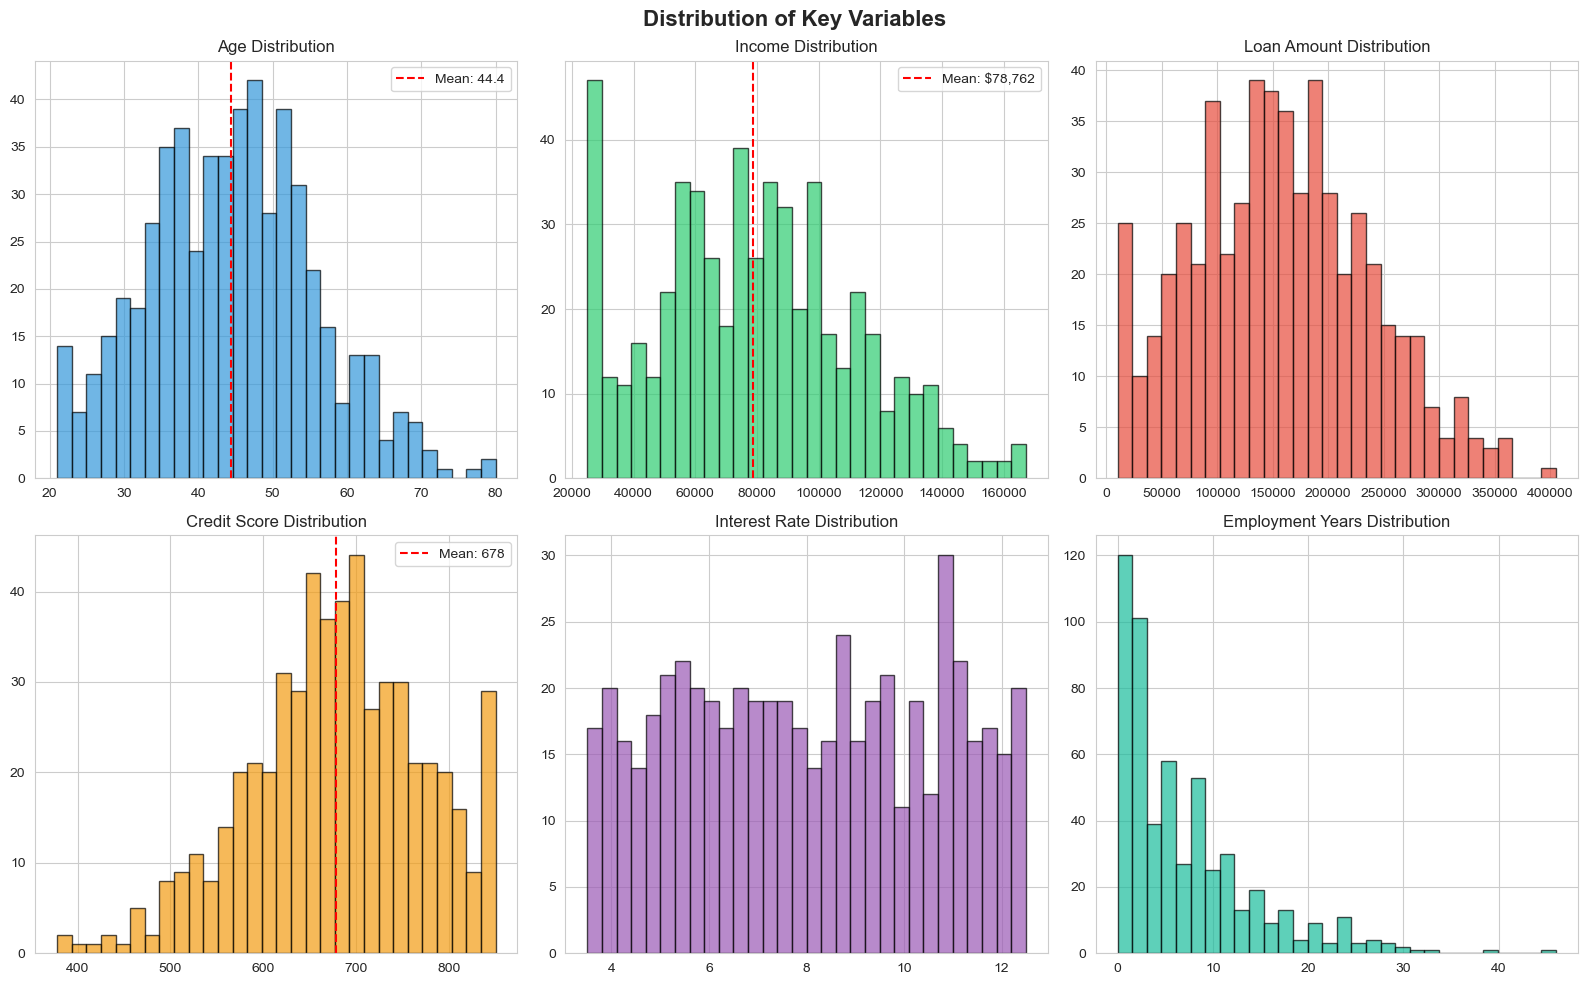

✓ Graph 1 saved!


In [8]:
import os
os.makedirs('images', exist_ok=True)

fig, axes = plt.subplots(2, 3, figsize=(16, 10))
fig.suptitle('Distribution of Key Variables', fontsize=16, fontweight='bold')

axes[0,0].hist(df['age'], bins=30, color='#3498db', edgecolor='black', alpha=0.7)
axes[0,0].set_title('Age Distribution')
axes[0,0].axvline(df['age'].mean(), color='red', linestyle='--', label=f'Mean: {df["age"].mean():.1f}')
axes[0,0].legend()

axes[0,1].hist(df['income'], bins=30, color='#2ecc71', edgecolor='black', alpha=0.7)
axes[0,1].set_title('Income Distribution')
axes[0,1].axvline(df['income'].mean(), color='red', linestyle='--', label=f'Mean: ${df["income"].mean():,.0f}')
axes[0,1].legend()

axes[0,2].hist(df['loan_amount'], bins=30, color='#e74c3c', edgecolor='black', alpha=0.7)
axes[0,2].set_title('Loan Amount Distribution')

axes[1,0].hist(df['credit_score'], bins=30, color='#f39c12', edgecolor='black', alpha=0.7)
axes[1,0].set_title('Credit Score Distribution')
axes[1,0].axvline(df['credit_score'].mean(), color='red', linestyle='--', label=f'Mean: {df["credit_score"].mean():.0f}')
axes[1,0].legend()

axes[1,1].hist(df['interest_rate'], bins=30, color='#9b59b6', edgecolor='black', alpha=0.7)
axes[1,1].set_title('Interest Rate Distribution')

axes[1,2].hist(df['employment_years'], bins=30, color='#1abc9c', edgecolor='black', alpha=0.7)
axes[1,2].set_title('Employment Years Distribution')

plt.tight_layout()
plt.savefig('images/01_distributions.png', dpi=300, bbox_inches='tight')
plt.show()
print("✓ Graph 1 saved!")

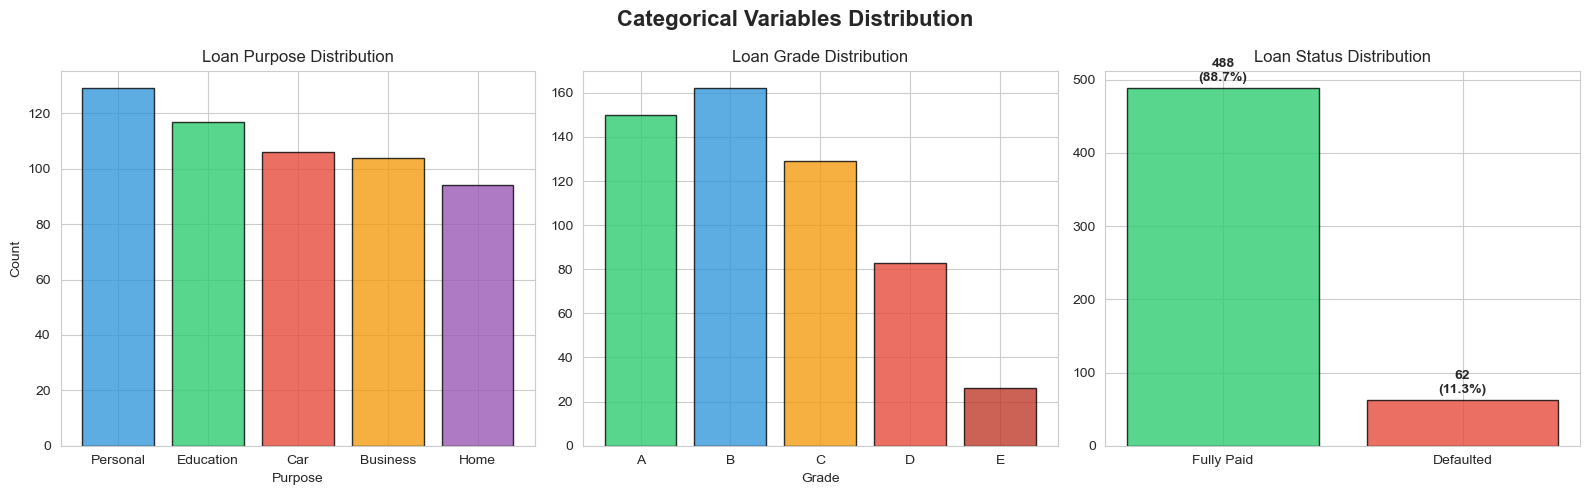

✓ Graph 2 saved!


In [9]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle('Categorical Variables Distribution', fontsize=16, fontweight='bold')

purpose_data = df['purpose'].value_counts()
axes[0].bar(purpose_data.index, purpose_data.values, 
            color=['#3498db', '#2ecc71', '#e74c3c', '#f39c12', '#9b59b6'], 
            alpha=0.8, edgecolor='black')
axes[0].set_title('Loan Purpose Distribution')
axes[0].set_xlabel('Purpose')
axes[0].set_ylabel('Count')

grade_data = df['grade'].value_counts().sort_index()
axes[1].bar(grade_data.index, grade_data.values, 
            color=['#2ecc71', '#3498db', '#f39c12', '#e74c3c', '#c0392b'], 
            alpha=0.8, edgecolor='black')
axes[1].set_title('Loan Grade Distribution')
axes[1].set_xlabel('Grade')

status_data = df['loan_status'].value_counts().sort_index()
axes[2].bar(['Fully Paid', 'Defaulted'], status_data.values, 
            color=['#2ecc71', '#e74c3c'], alpha=0.8, edgecolor='black')
axes[2].set_title('Loan Status Distribution')
for i, v in enumerate(status_data.values):
    pct = (v/len(df))*100
    axes[2].text(i, v+10, f'{v}\n({pct:.1f}%)', ha='center', fontweight='bold')

plt.tight_layout()
plt.savefig('images/02_categorical.png', dpi=300, bbox_inches='tight')
plt.show()
print("✓ Graph 2 saved!")

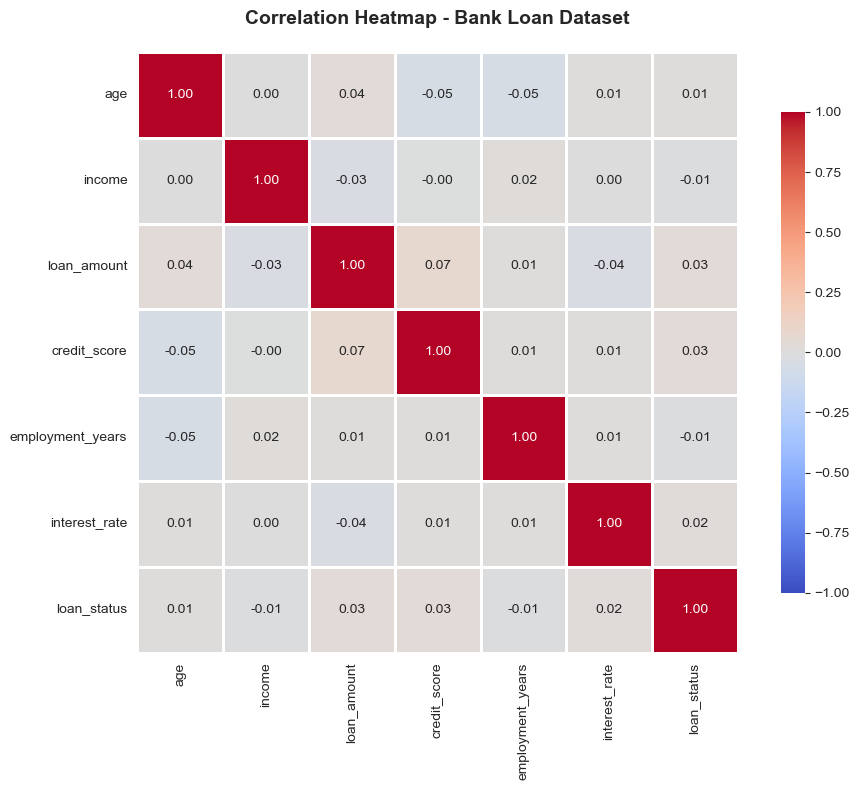

✓ Graph 3 - Correlation Heatmap saved!


In [10]:
numeric_columns = ['age', 'income', 'loan_amount', 'credit_score', 
                   'employment_years', 'interest_rate', 'loan_status']
correlation_matrix = df[numeric_columns].corr()

plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', center=0,
            fmt='.2f', square=True, linewidths=1, cbar_kws={"shrink": 0.8},
            vmin=-1, vmax=1)
plt.title('Correlation Heatmap - Bank Loan Dataset', 
          fontsize=14, fontweight='bold', pad=20)
plt.tight_layout()
plt.savefig('images/03_correlation_heatmap.png', dpi=300, bbox_inches='tight')
plt.show()
print("✓ Graph 3 - Correlation Heatmap saved!")

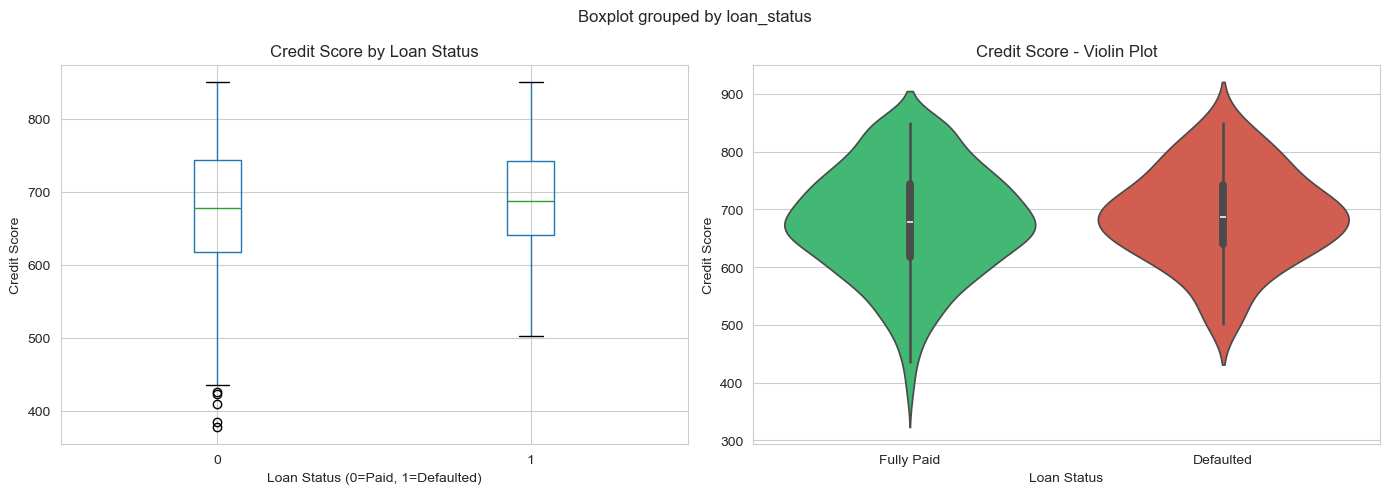

✓ Graph 4 saved!


In [11]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Credit Score Impact on Loan Default', fontsize=14, fontweight='bold')

df.boxplot(column='credit_score', by='loan_status', ax=axes[0])
axes[0].set_title('Credit Score by Loan Status')
axes[0].set_xlabel('Loan Status (0=Paid, 1=Defaulted)')
axes[0].set_ylabel('Credit Score')

sns.violinplot(data=df, x='loan_status', y='credit_score', 
               ax=axes[1], palette=['#2ecc71', '#e74c3c'])
axes[1].set_title('Credit Score - Violin Plot')
axes[1].set_xlabel('Loan Status')
axes[1].set_ylabel('Credit Score')
axes[1].set_xticklabels(['Fully Paid', 'Defaulted'])

plt.tight_layout()
plt.savefig('images/04_credit_score_vs_status.png', dpi=300, bbox_inches='tight')
plt.show()
print("✓ Graph 4 saved!")

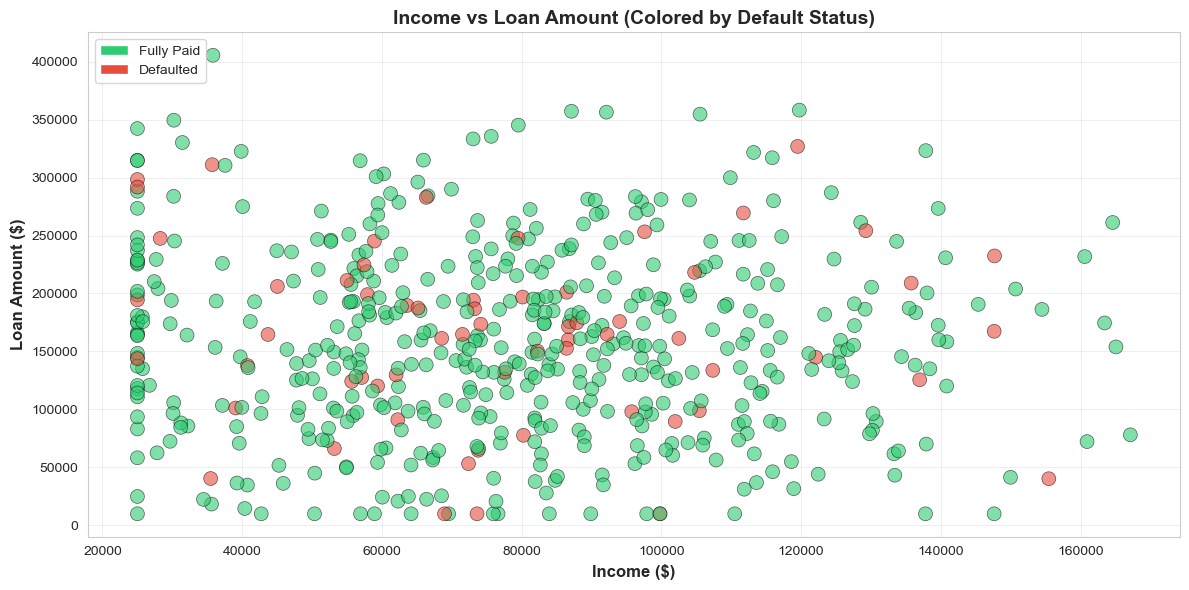

✓ Graph 5 saved!


In [12]:
plt.figure(figsize=(12, 6))

colors = ['#2ecc71' if x == 0 else '#e74c3c' for x in df['loan_status']]
plt.scatter(df['income'], df['loan_amount'], c=colors, alpha=0.6, 
            s=100, edgecolors='black', linewidth=0.5)

plt.xlabel('Income ($)', fontsize=12, fontweight='bold')
plt.ylabel('Loan Amount ($)', fontsize=12, fontweight='bold')
plt.title('Income vs Loan Amount (Colored by Default Status)', 
          fontsize=14, fontweight='bold')
plt.ticklabel_format(style='plain', axis='both')

from matplotlib.patches import Patch
legend_elements = [Patch(facecolor='#2ecc71', label='Fully Paid'),
                   Patch(facecolor='#e74c3c', label='Defaulted')]
plt.legend(handles=legend_elements, loc='upper left')

plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('images/05_income_vs_loan.png', dpi=300, bbox_inches='tight')
plt.show()
print("✓ Graph 5 saved!")

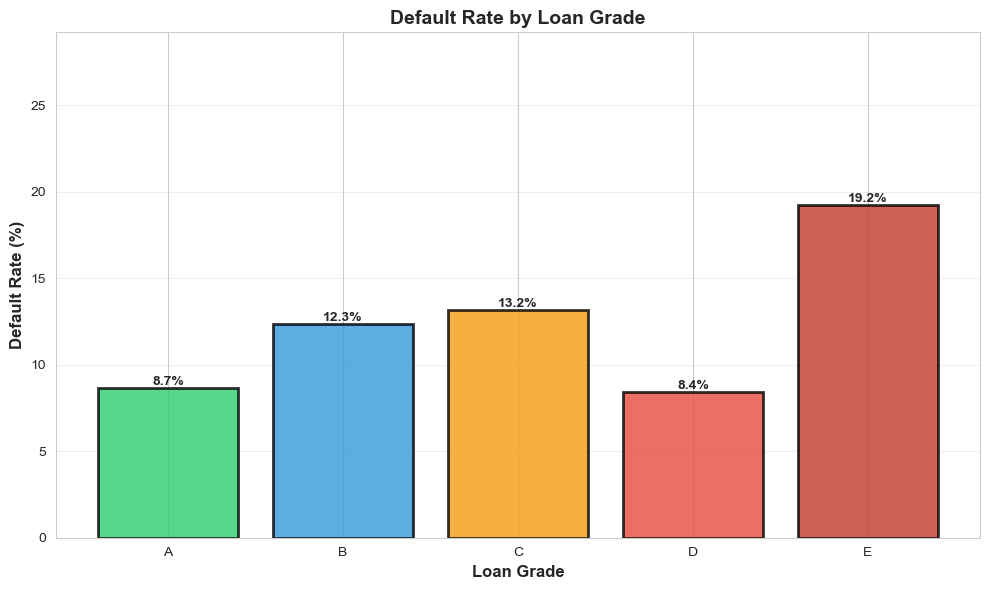

✓ Graph 6 saved!
       sum  count  default_rate
grade                          
A       13    150          8.67
B       20    162         12.35
C       17    129         13.18
D        7     83          8.43
E        5     26         19.23


In [13]:
default_by_grade = df.groupby('grade')['loan_status'].agg(['sum', 'count'])
default_by_grade['default_rate'] = (default_by_grade['sum'] / default_by_grade['count'] * 100).round(2)

plt.figure(figsize=(10, 6))
bars = plt.bar(default_by_grade.index, default_by_grade['default_rate'],
               color=['#2ecc71', '#3498db', '#f39c12', '#e74c3c', '#c0392b'],
               alpha=0.8, edgecolor='black', linewidth=2)

plt.xlabel('Loan Grade', fontsize=12, fontweight='bold')
plt.ylabel('Default Rate (%)', fontsize=12, fontweight='bold')
plt.title('Default Rate by Loan Grade', fontsize=14, fontweight='bold')
plt.ylim(0, max(default_by_grade['default_rate']) + 10)

for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2., height,
             f'{height:.1f}%', ha='center', va='bottom', fontweight='bold')

plt.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.savefig('images/06_default_by_grade.png', dpi=300, bbox_inches='tight')
plt.show()
print("✓ Graph 6 saved!")
print(default_by_grade)

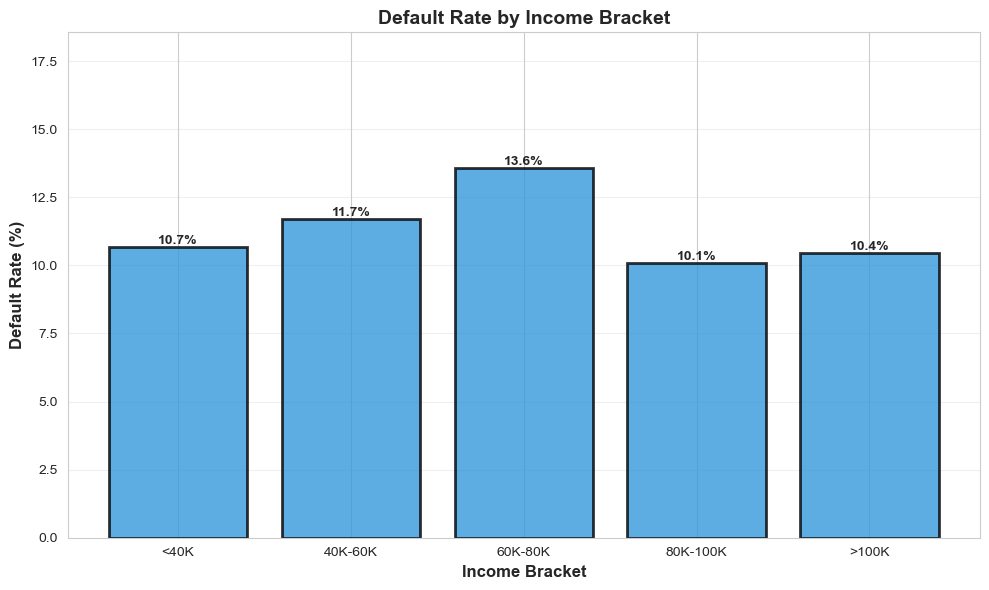

✓ Graph 7 saved!


In [14]:
df['income_bracket'] = pd.cut(df['income'],
                               bins=[0, 40000, 60000, 80000, 100000, 300000],
                               labels=['<40K', '40K-60K', '60K-80K', '80K-100K', '>100K'])

default_by_income = df.groupby('income_bracket')['loan_status'].agg(['sum', 'count'])
default_by_income['default_rate'] = (default_by_income['sum'] / default_by_income['count'] * 100).round(2)

plt.figure(figsize=(10, 6))
bars = plt.bar(range(len(default_by_income)), default_by_income['default_rate'],
               color='#3498db', alpha=0.8, edgecolor='black', linewidth=2)

plt.xlabel('Income Bracket', fontsize=12, fontweight='bold')
plt.ylabel('Default Rate (%)', fontsize=12, fontweight='bold')
plt.title('Default Rate by Income Bracket', fontsize=14, fontweight='bold')
plt.xticks(range(len(default_by_income)), default_by_income.index)
plt.ylim(0, max(default_by_income['default_rate']) + 5)

for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2., height,
             f'{height:.1f}%', ha='center', va='bottom', fontweight='bold')

plt.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.savefig('images/07_default_by_income.png', dpi=300, bbox_inches='tight')
plt.show()
print("✓ Graph 7 saved!")

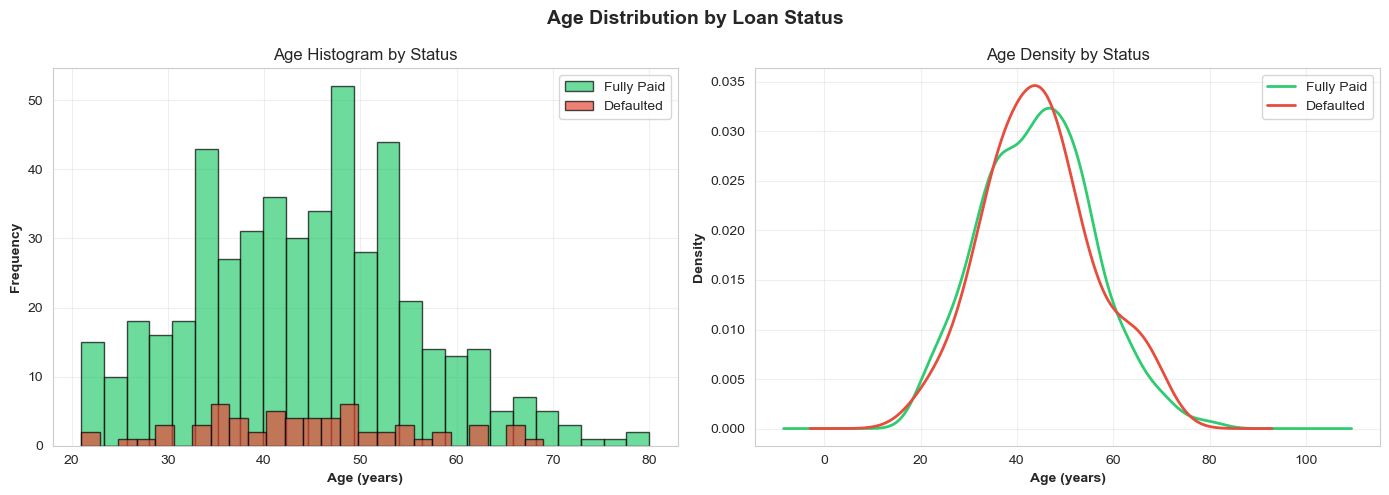

✓ Graph 8 saved!


In [15]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Age Distribution by Loan Status', fontsize=14, fontweight='bold')

df[df['loan_status'] == 0]['age'].hist(bins=25, alpha=0.7, label='Fully Paid', 
                                        color='#2ecc71', ax=axes[0], edgecolor='black')
df[df['loan_status'] == 1]['age'].hist(bins=25, alpha=0.7, label='Defaulted', 
                                        color='#e74c3c', ax=axes[0], edgecolor='black')
axes[0].set_xlabel('Age (years)', fontweight='bold')
axes[0].set_ylabel('Frequency', fontweight='bold')
axes[0].set_title('Age Histogram by Status')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

df[df['loan_status'] == 0]['age'].plot(kind='kde', ax=axes[1], 
                                        label='Fully Paid', color='#2ecc71', linewidth=2)
df[df['loan_status'] == 1]['age'].plot(kind='kde', ax=axes[1], 
                                        label='Defaulted', color='#e74c3c', linewidth=2)
axes[1].set_xlabel('Age (years)', fontweight='bold')
axes[1].set_ylabel('Density', fontweight='bold')
axes[1].set_title('Age Density by Status')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('images/08_age_by_status.png', dpi=300, bbox_inches='tight')
plt.show()
print("✓ Graph 8 saved!")

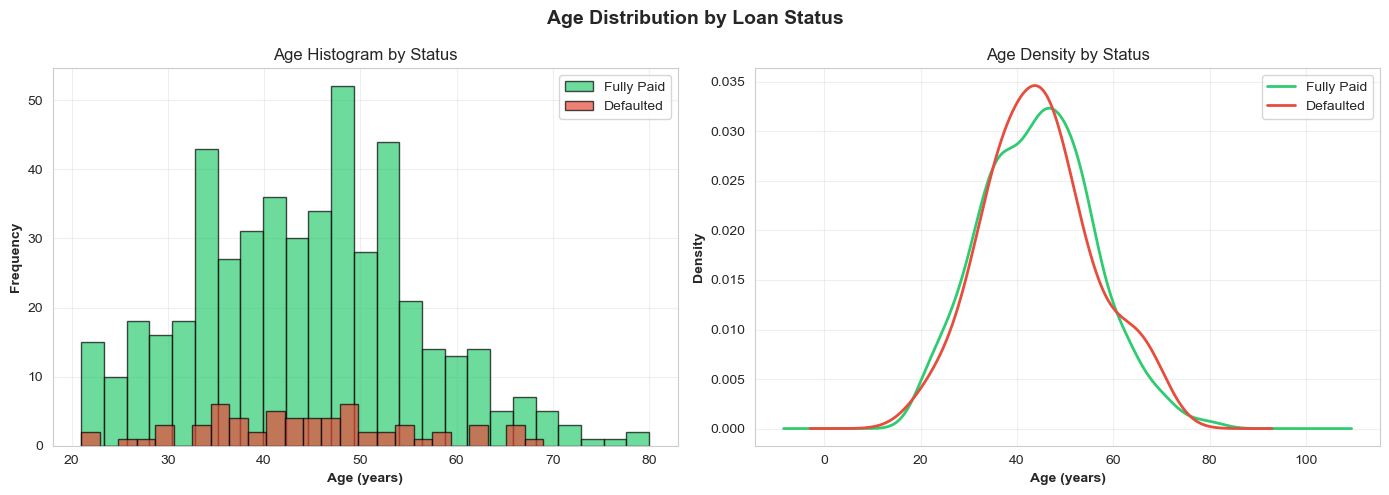

✓ Graph 8 saved!


In [16]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Age Distribution by Loan Status', fontsize=14, fontweight='bold')

df[df['loan_status'] == 0]['age'].hist(bins=25, alpha=0.7, label='Fully Paid', 
                                        color='#2ecc71', ax=axes[0], edgecolor='black')
df[df['loan_status'] == 1]['age'].hist(bins=25, alpha=0.7, label='Defaulted', 
                                        color='#e74c3c', ax=axes[0], edgecolor='black')
axes[0].set_xlabel('Age (years)', fontweight='bold')
axes[0].set_ylabel('Frequency', fontweight='bold')
axes[0].set_title('Age Histogram by Status')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

df[df['loan_status'] == 0]['age'].plot(kind='kde', ax=axes[1], 
                                        label='Fully Paid', color='#2ecc71', linewidth=2)
df[df['loan_status'] == 1]['age'].plot(kind='kde', ax=axes[1], 
                                        label='Defaulted', color='#e74c3c', linewidth=2)
axes[1].set_xlabel('Age (years)', fontweight='bold')
axes[1].set_ylabel('Density', fontweight='bold')
axes[1].set_title('Age Density by Status')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('images/08_age_by_status.png', dpi=300, bbox_inches='tight')
plt.show()
print("✓ Graph 8 saved!")

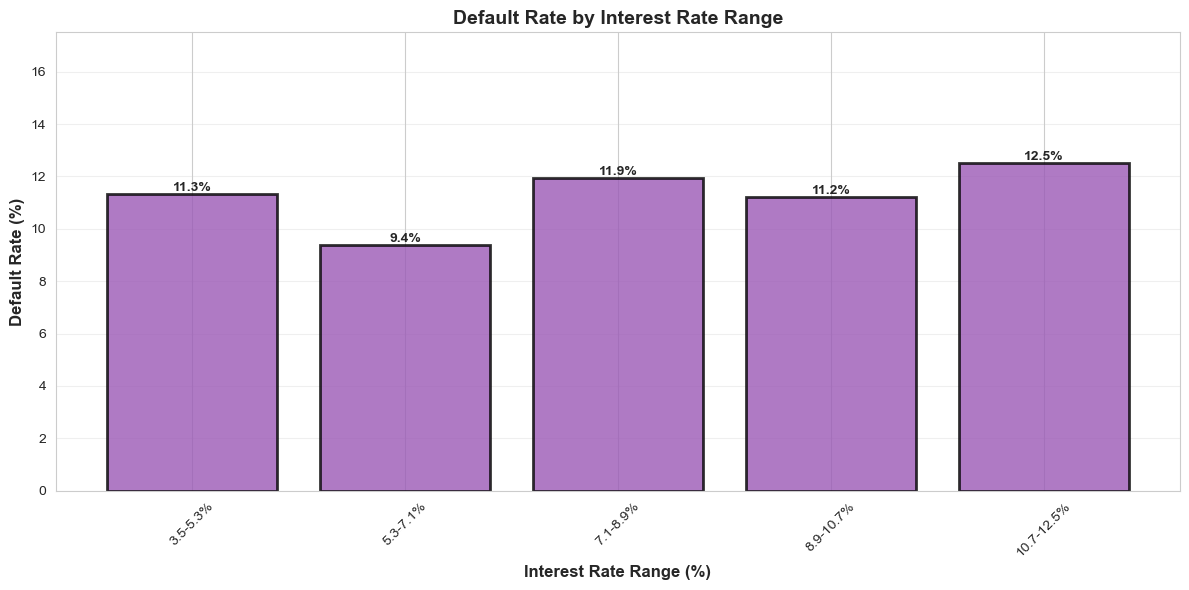

✓ Graph 9 saved!


In [17]:
df['interest_bucket'] = pd.cut(df['interest_rate'], bins=5)
interest_default = df.groupby('interest_bucket')['loan_status'].agg(['sum', 'count'])
interest_default['default_rate'] = (interest_default['sum'] / interest_default['count'] * 100).round(2)

plt.figure(figsize=(12, 6))
bars = plt.bar(range(len(interest_default)), interest_default['default_rate'],
               color='#9b59b6', alpha=0.8, edgecolor='black', linewidth=2)

plt.xlabel('Interest Rate Range (%)', fontsize=12, fontweight='bold')
plt.ylabel('Default Rate (%)', fontsize=12, fontweight='bold')
plt.title('Default Rate by Interest Rate Range', fontsize=14, fontweight='bold')
plt.xticks(range(len(interest_default)), 
           [f'{x.left:.1f}-{x.right:.1f}%' for x in interest_default.index], 
           rotation=45)
plt.ylim(0, max(interest_default['default_rate']) + 5)

for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2., height,
             f'{height:.1f}%', ha='center', va='bottom', fontweight='bold')

plt.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.savefig('images/09_interest_vs_default.png', dpi=300, bbox_inches='tight')
plt.show()
print("✓ Graph 9 saved!")